In [55]:
import subprocess
from dataclasses import dataclass
from typing import List

import matplotlib.pyplot as plt
import numpy as np

file_num = 1000

In [56]:


# 色ベクトルは長さ3の浮動小数点リスト
Color = List[float]

@dataclass
class Input:
    N: int
    K: int
    H: int
    T: int
    D: int
    own: List[Color]
    target: List[Color]

def parse_input(file_path: str) -> Input:
    """
    ファイルを空白区切りで読み込み、
    最初に N, K, H, T, D の5つの整数を、
    続いて K 個の own カラー (各3つの浮動小数点)、
    H 個の target カラー (各3つの浮動小数点) を読み取ります。
    """
    with open(file_path, 'r') as f:
        # 全トークンを取得
        tokens = f.read().split()
    it = iter(tokens)
    # ヘッダ部
    N = int(next(it))
    K = int(next(it))
    H = int(next(it))
    T = int(next(it))
    D = int(next(it))
    # own カラー K×3
    own: List[Color] = [
        [float(next(it)) for _ in range(3)]
        for _ in range(K)
    ]
    # target カラー H×3
    target: List[Color] = [
        [float(next(it)) for _ in range(3)]
        for _ in range(H)
    ]
    return Input(N=N, K=K, H=H, T=T, D=D, own=own, target=target)

In [57]:
input_datas = []
for i in range(file_num):
    file_path = f"../tools/in/{i:04d}.txt"
    input_data = parse_input(file_path)
    input_datas.append(input_data)

In [58]:
scores = []
for i in range(file_num):
    file_path = f"../tools/err/{i:04d}.txt"
    with open(file_path, 'r') as f:
        score, turn = f.readlines()[-1].strip().split()
        scores.append(int(score))

scores2 = []
for i in range(file_num):
    file_path = f"../tools/err2/{i:04d}.txt"
    with open(file_path, 'r') as f:
        score, turn = f.readlines()[-1].strip().split()
        scores2.append(int(score))

In [59]:
turns = []
d_costs = []
for input_data in input_datas:
    turns.append(input_data.T)
    d_costs.append(input_data.D)

In [77]:
import pandas as pd

df = pd.DataFrame({
    'score': scores,
    'score2': scores2,
    'turn': turns,
    'd_cost': d_costs
})

In [81]:
df1 = pd.DataFrame({'score': scores, 't': turns, 'd': d_costs,'experiment': 'exp1'})
df2 = pd.DataFrame({'score': scores2, 't': turns,  'd': d_costs,'experiment': 'exp2',})
df = pd.concat([df1, df2])

In [82]:
# tのbin幅を決める（例：8000ごと）
bin_width = 4000
bins = np.arange(4000, 64000 + bin_width, bin_width)
labels = [f"{b}-{b+bin_width-1}" for b in bins[:-1]]
df['t_bin'] = pd.cut(df['t'], bins=bins, labels=labels, include_lowest=True)
df

,score,t,d,experiment,t_bin
0,269789,60887,3822,exp1,60000-63999
1,153950,23052,13,exp1,20000-23999
2,463707,9827,1392,exp1,8000-11999
3,120336,4349,14,exp1,4000-7999
4,234663,25343,465,exp1,24000-27999
...,...,...,...,...,...
995,3160,29568,1002,exp2,28000-31999
996,14030,24733,8000,exp2,24000-27999
997,792033,4199,24,exp2,4000-7999
998,1540323,4946,1552,exp2,4000-7999


In [84]:
pd.options.display.max_rows = 1000
df2[(df2["t"] >= 19000)].head(1000)

,score,t,d,experiment
0,8149,60887,3822,exp2
1,600,23052,13,exp2
4,2271,25343,465,exp2
5,4513,63725,2746,exp2
11,1607,28008,47,exp2
14,1231,58777,113,exp2
15,985,29892,31,exp2
18,1804,27695,591,exp2
19,959,52006,31,exp2
25,300,56437,108,exp2


In [63]:
agg = df.groupby(['t_bin', 'experiment']).agg(
    mean_score=('score', 'mean'),
    mean_log_score=('score', lambda x: np.mean(np.log(x + 1e-8)))  # 0除算防止で微小値加算
).reset_index()

/tmp/ipykernel_1738134/1928647825.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby(['t_bin', 'experiment']).agg(


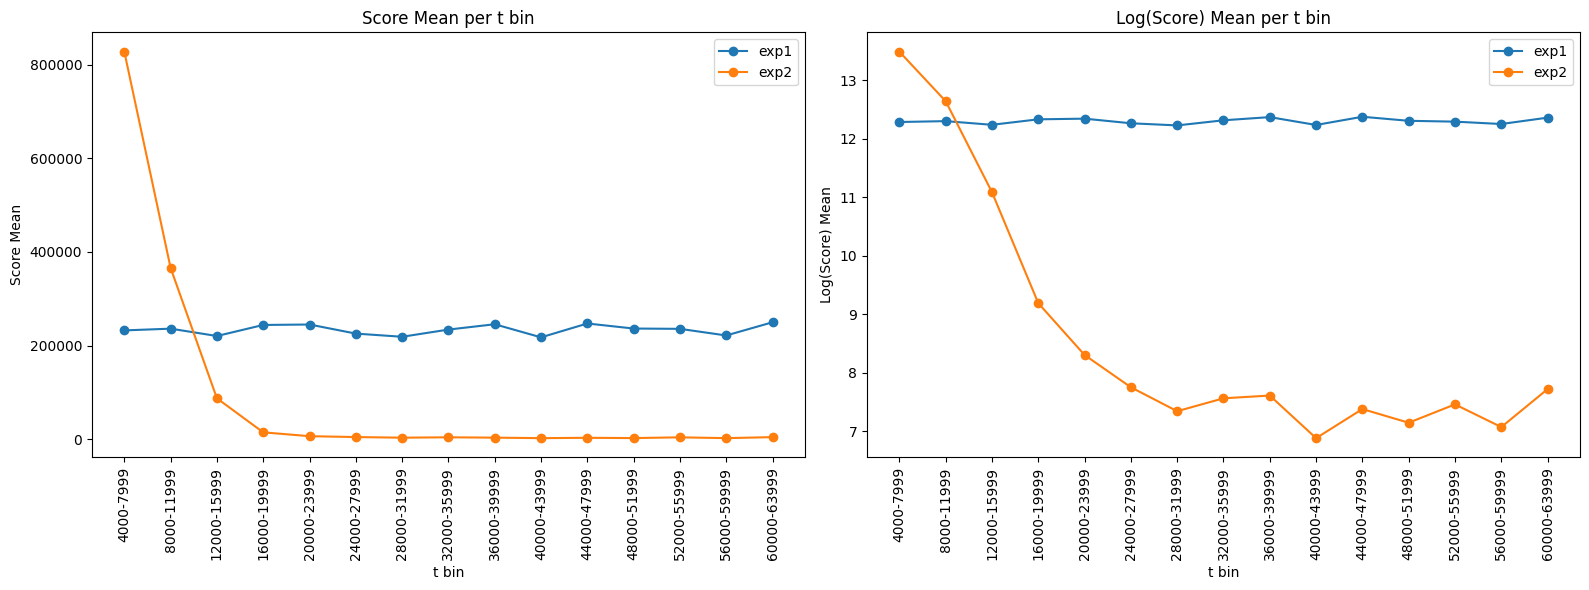

In [64]:

# プロット
fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

for exp in ['exp1', 'exp2']:
    sub = agg[agg['experiment'] == exp]
    axs[0].plot(sub['t_bin'], sub['mean_score'], marker='o', label=exp)
    axs[1].plot(sub['t_bin'], sub['mean_log_score'], marker='o', label=exp)

axs[0].set_title('Score Mean per t bin')
axs[0].set_ylabel('Score Mean')
axs[1].set_title('Log(Score) Mean per t bin')
axs[1].set_ylabel('Log(Score) Mean')
for ax in axs:
    ax.set_xlabel('t bin')
    ax.legend()
    ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

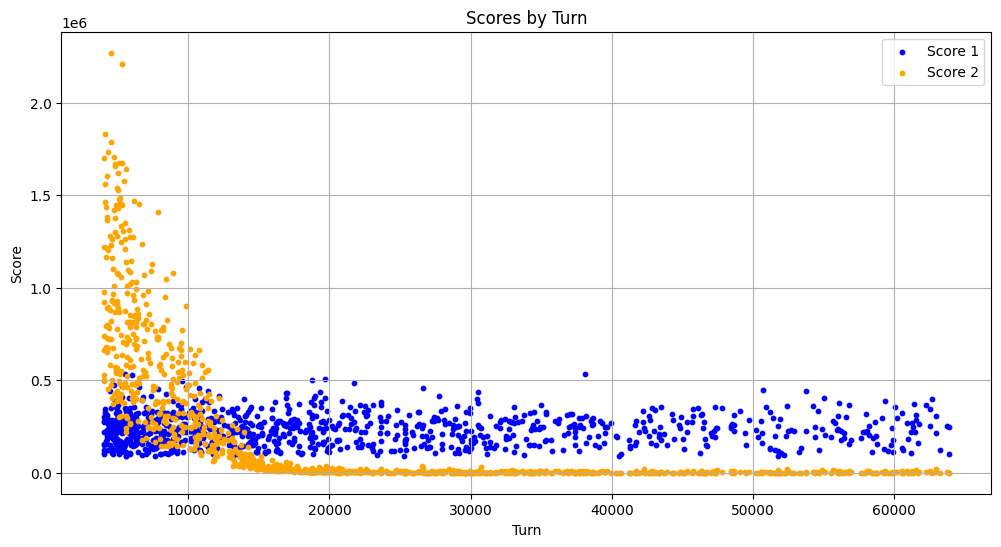

In [67]:



# ターン毎の、score1とscore2の分布を可視化
def plot_scores(turns, scores, scores2):
    plt.figure(figsize=(12, 6))
    plt.scatter(turns, scores, label='Score 1', color='blue', s=10)
    plt.scatter(turns, scores2, label='Score 2', color='orange', s=10)
    plt.xlabel('Turn')
    plt.ylabel('Score')
    plt.title('Scores by Turn')
    plt.legend()
    plt.grid()
    plt.show()

plot_scores(turns, scores, scores2)

In [6]:
np.log(0.001)

np.float64(-6.907755278982137)

Text(0.5, 1.0, 'Square Root Function')

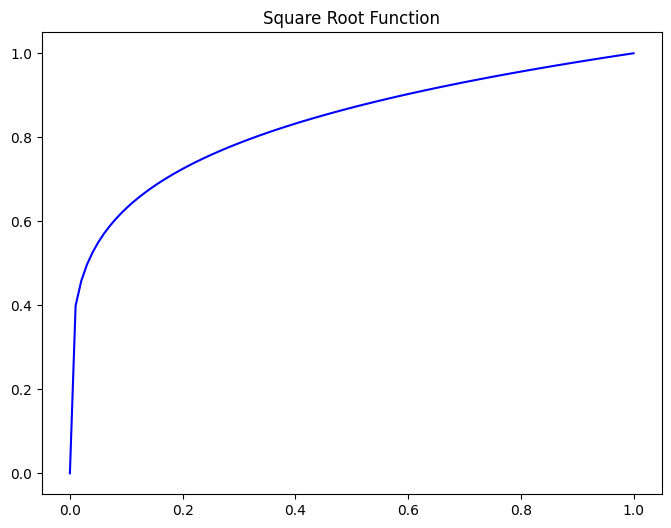

In [13]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 1, 100)
root_x = np.power(x, 0.2)  # xの平方根を計算

plt.figure(figsize=(8, 6))
plt.plot(x, root_x, label='Square Root', color='blue')
plt.title('Square Root Function')
